# 01 · 从模仿到纠错：跑完一个机器人学习闭环

**你的研究问题：机械臂在专家数据上预测得不错，实际执行却走偏，应该补什么数据？**

这不是环境安装测试。你会生成原始轨迹、检查数据、训练神经网络、保存并加载模型、让它在 MuJoCo 中真正执行、诊断失败、做一次有对照的改进，最后写研究复盘。

对应你熟悉的量化工作流：`行情与标签 → signal 拟合 → 冻结模型 → 回测 → 归因 → 迭代`。
机器人里对应：`状态与专家动作 → 策略拟合 → checkpoint → 闭环 rollout → 失败诊断 → 纠正数据`。

**最关键的区别**：动作改变下一时刻的状态，也改变模型下一次会看到的数据。因此离线预测误差小，不自动等于控制效果好。交易有冲击和反馈时也会遇到类似问题。

## 你要交付什么

1. 一份可审计的轨迹数据和动作标签。
2. 一个重新加载后可执行的策略。
3. 一个公平对照表：BC、多训练、更多普通演示、DAgger 式纠正。
4. 一页回答“什么有效、证据是什么、下一步怎么验证”的复盘。

**第一遍**逐格运行，不改参数；先用 60–90 分钟理解与记笔记，机器运行耗时会实际记录。第二遍才改一个变量。本文默认 CPU、2 个 PyTorch 计算线程，不需要 AWS 或真机。

### 打开与运行

保留整个 `robot_learning_loops` 文件夹；在其目录里执行：
```bash
uv sync --locked --group notebooks
uv run --group notebooks jupyter lab notebooks/01_机械臂模仿学习.ipynb
```
Jupyter 中按 **Shift+Enter** 逐格运行；需要整体复验时用 **Kernel → Restart Kernel and Run All Cells**。
交付版已经保存了实际执行输出，未安装环境也可以先读同目录 HTML。Notebook 中的变量只存在于当前 kernel，跳格运行会导致 `NameError`。

**范围**：二维、低维状态、无接触的 Reacher 教学任务；不是图像抓取或论文分数复现。动画来自实际模拟状态的示意绘制。

## 1 · 先写实验协议，再看结果

这里的“一次 episode”是从初始机械臂状态开始的 50 步控制，总长 1 秒。
第一遍用 80 条训练轨迹、16 条验证轨迹、30 个评测初始条件。评测集合是**开发基准**，不是反复看结果后仍可声称未触碰的最终测试集。

先写下你的预测：**多训练、更多演示、走偏后的纠正，哪个最可能降低执行误差？为什么？**

In [1]:
QUICK = False  # True 仅做小预算链路检查，不保证出现同样的改进
SEED = 7
N_TRAIN = 24 if QUICK else 80
UPDATES = 400 if QUICK else 2000
N_EVAL = 8 if QUICK else 30
N_EXTRA = max(8, N_TRAIN // 2)
MY_PREDICTION = "待填写：我预测……因为……"
print(dict(seed=SEED, train_episodes=N_TRAIN, updates_per_phase=UPDATES,
           extra_episodes=N_EXTRA, evaluation_episodes=N_EVAL))

{'seed': 7, 'train_episodes': 80, 'updates_per_phase': 2000, 'extra_episodes': 40, 'evaluation_episodes': 30}


In [3]:
from pathlib import Path
import sys, time, json, copy, hashlib, base64
from argparse import Namespace

# 支持从项目根目录或 notebooks/ 启动；移动时请移动整个项目。
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "loop01_imitation.py").exists()), None)
if ROOT is None:
    raise RuntimeError("请在完整 robot_learning_loops 文件夹内启动 Notebook。")
sys.path.insert(0, str(ROOT)) if str(ROOT) not in sys.path else None

import numpy as np
import pandas as pd
import torch
import gymnasium as gym
from IPython.display import display, Image, Markdown, HTML
from common import setup_torch, start_run, plt, arm_frame, summarize, write_paired_delta
from loop01_imitation import Actor, collect, evaluate

def show_gif(path):
    encoded = base64.b64encode(Path(path).read_bytes()).decode("ascii")
    display(HTML(f'<img alt="Actual MuJoCo trajectory schematic" width="480" src="data:image/gif;base64,{encoded}">'))

START = time.perf_counter()
setup_torch(SEED, "cpu")
OUT = start_run("notebook01", Namespace(seed=SEED, device="cpu", quick=QUICK,
                 episodes=N_TRAIN, updates=UPDATES, eval_episodes=N_EVAL,
                 extra_episodes=N_EXTRA))
manifest = json.loads((OUT / "manifest.json").read_text())
notebook_source = json.loads((ROOT / "notebooks" / "01_机械臂模仿学习.ipynb").read_text())
source_bytes = json.dumps([c["source"] for c in notebook_source["cells"]], ensure_ascii=False).encode()
manifest["notebook_source_sha256"] = hashlib.sha256(source_bytes).hexdigest()
(OUT / "manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
print("Python:", sys.executable)
print("计算线程:", torch.get_num_threads())
display(pd.Series(manifest["versions"], name="version").to_frame())

Run directory: /Users/yddy/Desktop/playground/robotics2026/robot_learning_loops/runs/notebook01-20260910-101405-569000
Python: /Users/yddy/Desktop/playground/robotics2026/robot_learning_loops/.venv/bin/python
计算线程: 2


,version
numpy,2.5.3
torch,2.14.0
gymnasium,1.3.0
mujoco,3.12.0
stable-baselines3,2.9.0


## 2 · 任务合同：输入、动作、目标和时间

模型输入 $o_t$ 是 10 维观测，输出 $a_t$ 是 2 维电机控制命令。
MuJoCo 根据动力学计算下一状态：$s_{t+1}=f(s_t,a_t)$，然后模型再读新的观测。

本任务用末端到目标的二维距离评测，**越小越好**。自定义成功条件：最后 10 步平均距离小于 2.5 cm。它不是官方 leaderboard 的成功率定义。

动作范围是 [-1,1]，执行器 gear 是 200；动作数值不能直接当作牛米扭矩。
**运行后确认**：观测维度 10、动作维度 2、控制周期 0.02 秒。先弄清字段语义，再开始建模，就像不能把 mid price 当成交价。

,feature,value
0,cos(q1),0.998499
1,cos(q2),0.999925
2,sin(q1),0.054764
3,sin(q2),-0.012224
4,target_x,0.104456
5,target_y,0.114426
6,velocity_q1,-0.003719
7,velocity_q2,-0.000496
8,tip_minus_target_x,0.105294
9,tip_minus_target_y,-0.104268


action bounds: [-1. -1.] [1. 1.]
dt: 0.02 seconds; gear: [200. 200.]


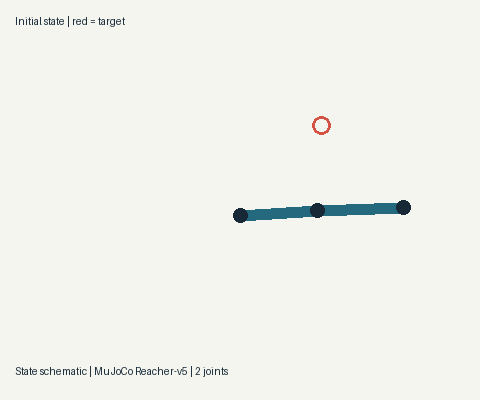

CPU times: user 8.07 ms, sys: 1.01 ms, total: 9.09 ms
Wall time: 9.51 ms


In [5]:
%%time
env = gym.make("Reacher-v5")
obs, _ = env.reset(seed=42)
DT = env.unwrapped.dt
features = ["cos(q1)", "cos(q2)", "sin(q1)", "sin(q2)",
            "target_x", "target_y", "velocity_q1", "velocity_q2", "tip_minus_target_x", "tip_minus_target_y"]
display(pd.DataFrame({"feature": features, "value": obs}))
print("action bounds:", env.action_space.low, env.action_space.high)
print("dt:", DT, "seconds; gear:", env.unwrapped.model.actuator_gear[:2, 0])
display(arm_frame(env.unwrapped.data.qpos[:2], env.unwrapped.data.qpos[2:4], "Initial state | red = target"))
env.close()

,feature,value
0,cos(q1),0.996568
1,cos(q2),0.998615
2,sin(q1),-0.082775
3,sin(q2),-0.052614
4,target_x,-0.162349
5,target_y,-0.026749
6,velocity_q1,-0.000209
7,velocity_q2,-0.003403
8,tip_minus_target_x,0.370997
9,tip_minus_target_y,0.003611


action bounds: [-1. -1.] [1. 1.]
dt: 0.02 seconds; gear: [200. 200.]


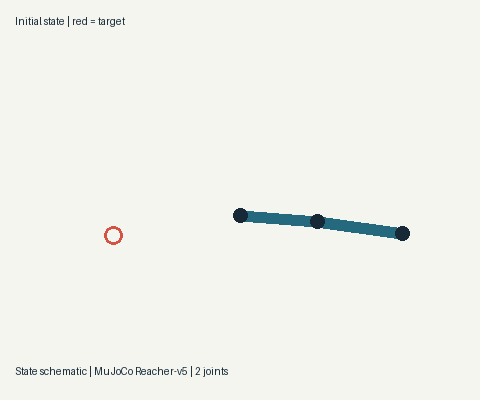

CPU times: user 11 ms, sys: 1.96 ms, total: 13 ms
Wall time: 11.2 ms


In [6]:
%%time
env = gym.make("Reacher-v5")
obs, _ = env.reset(seed=3)
DT = env.unwrapped.dt
features = ["cos(q1)", "cos(q2)", "sin(q1)", "sin(q2)",
            "target_x", "target_y", "velocity_q1", "velocity_q2", "tip_minus_target_x", "tip_minus_target_y"]
display(pd.DataFrame({"feature": features, "value": obs}))
print("action bounds:", env.action_space.low, env.action_space.high)
print("dt:", DT, "seconds; gear:", env.unwrapped.model.actuator_gear[:2, 0])
display(arm_frame(env.unwrapped.data.qpos[:2], env.unwrapped.data.qpos[2:4], "Initial state | red = target"))
env.close()

## 3 · 生成 raw data：先收集专家行为

本练习的专家是“逆运动学 + 基于模型的控制器”。它能访问模拟器的动力学，是一个拥有额外信息的老师；学生只用上面的 10 维观测。专家实现位于 `loop01_imitation.py::expert_action`，第一遍先把它当可靠的标签产生器，后续再学 IK、PD 与逆动力学。

一行数据为 $(o_t, a_t^*, a_t^{executed}, o_{t+1}, r_t, episode, t)$。
`expert_action` 是应学的标签，`executed_action` 是真正施加的命令。训练采集加入小噪声，因此这两列**有意不同**。

采集顺序：读观测 → 查询专家 → 执行动作 → 保存下一观测。动作不能错位到下一行。

In [7]:
train = collect(range(N_TRAIN), noise=.015, rng_seed=SEED)
val = collect(range(1000, 1016), rng_seed=SEED + 1)
np.savez_compressed(OUT / "raw_train.npz", **train)
np.savez_compressed(OUT / "raw_validation.npz", **val)
display(pd.DataFrame({"field": list(train), "shape": [str(v.shape) for v in train.values()],
                      "dtype": [str(v.dtype) for v in train.values()]}))
display(pd.DataFrame({"episode": train["episode"][:8], "step": train["step"][:8],
                      "seconds": train["sample_time"][:8],
                      "expert_a0": train["expert_action"][:8, 0],
                      "executed_a0": train["executed_action"][:8, 0]}))

,field,shape,dtype
0,obs,"(4000, 10)",float64
1,expert_action,"(4000, 2)",float32
2,executed_action,"(4000, 2)",float32
3,next_obs,"(4000, 10)",float64
4,episode,"(4000,)",int64
5,step,"(4000,)",int64
6,sample_time,"(4000,)",float64
7,reward,"(4000,)",float64
8,terminated,"(4000,)",bool
9,truncated,"(4000,)",bool


,episode,step,seconds,expert_a0,executed_a0
0,0,0,0.00,-0.023884,-0.023866
1,0,1,0.02,-0.014315,-0.018427
2,0,2,0.04,-0.006262,-0.013082
3,0,3,0.06,0.000222,0.001124
4,0,4,0.08,0.001459,-0.005924
5,0,5,0.10,0.005417,0.012765
6,0,6,0.12,0.002130,0.003711
7,0,7,0.14,0.001995,0.001557


## 4 · 数据清理与切分：先做门禁，不盲目删行

模拟数据仍然可能有错位、非有限数、episode 混淆和单位错误。这里的数据干净，所以“清理”主要是审计。
发现不可信轨迹时应隔离并定位原因；随意删时间序列的单行会破坏 transition 连续性。

训练/验证按完整 episode 的初始种子切分，避免同一轨迹相邻帧流到两个集合。它不证明 OOD 泛化；目标区域和动力学仍来自相同分布。
下面故意往**副本**中放一个 NaN，确认检查真的能拦住坏数据。

In [8]:
def audit(data):
    n = len(data["obs"])
    assert data["obs"].shape == (n, 10)
    assert data["expert_action"].shape == (n, 2)
    assert all(len(v) == n for v in data.values())
    for key in ["obs", "expert_action", "executed_action", "next_obs", "reward", "sample_time"]:
        assert np.isfinite(data[key]).all(), f"{key}: non-finite value"
    for key in ["expert_action", "executed_action"]:
        assert np.abs(data[key]).max() <= 1
    for episode in np.unique(data["episode"]):
        idx = np.flatnonzero(data["episode"] == episode)
        assert np.array_equal(data["step"][idx], np.arange(len(idx)))
        np.testing.assert_allclose(data["sample_time"][idx], np.arange(len(idx)) * DT)
        np.testing.assert_allclose(data["next_obs"][idx[:-1]], data["obs"][idx[1:]])
        assert not (data["terminated"][idx[:-1]] | data["truncated"][idx[:-1]]).any()
        assert bool(data["terminated"][idx[-1]] or data["truncated"][idx[-1]])
    return {"rows": n, "episodes": len(np.unique(data["episode"])), "audit": "PASS"}

assert not set(train["episode"]) & set(val["episode"])
audit_table = pd.DataFrame([audit(train), audit(val)], index=["train", "validation"])
display(audit_table)
audit_table.to_csv(OUT / "data_audit.csv")
bad = {k: v.copy() for k, v in train.items()}
bad["obs"][0, 0] = np.nan
try:
    audit(bad)
except AssertionError as exc:
    print("预期拦截：", exc)
else:
    raise AssertionError("检查未能拦截故意损坏的数据")
del bad

,rows,episodes,audit
train,4000,80,PASS
validation,800,16,PASS


预期拦截： obs: non-finite value


In [14]:
 train["episode"] 

array([ 0,  0,  0, ..., 79, 79, 79], shape=(4000,))

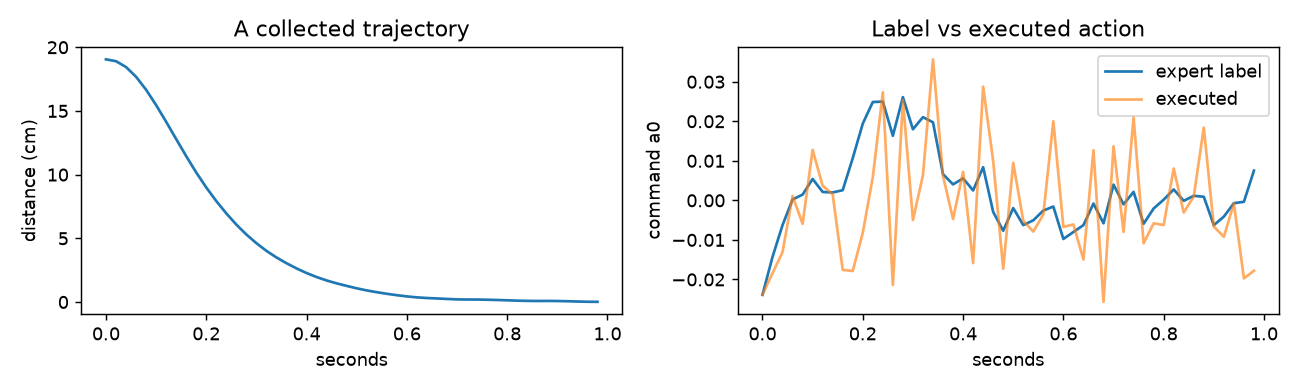

In [15]:
mask = train["episode"] == 0
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(train["sample_time"][mask], np.linalg.norm(train["obs"][mask, -2:], axis=1) * 100)
axes[0].set(xlabel="seconds", ylabel="distance (cm)", title="A collected trajectory")
axes[1].plot(train["sample_time"][mask], train["expert_action"][mask, 0], label="expert label")
axes[1].plot(train["sample_time"][mask], train["executed_action"][mask, 0], label="executed", alpha=.65)
axes[1].set(xlabel="seconds", ylabel="command a0", title="Label vs executed action")
axes[1].legend()
fig.tight_layout(); fig.savefig(OUT / "raw_trajectory.png", dpi=130)
display(Image(filename=str(OUT / "raw_trajectory.png"))); plt.close(fig)

**停下来解释**：为什么训练标签用专家动作，而不是带噪声的执行动作？为什么这里没有要求把 observation 和 next_observation 的每一维都标准化成同一种物理单位？

## 5 · 训练 BC：一个你熟悉的监督学习问题

Behavior Cloning（行为克隆）用神经网络近似 $\pi_\theta(o_t)\approx a_t^*$。
我们只用训练集估计输入/动作的均值和标准差，再最小化标准化动作的 MSE。

网络是 `10 → 128 → 128 → 2` 的小型 MLP。优化器是 Adam、batch=256、梯度裁剪=5。
下面的训练循环直接写在 Notebook 里；无需先掌握整篇机器人论文。

**要区分两个数**：训练曲线是标准化动作 MSE，验证曲线是原始动作尺度 MSE，数值不能互相比大小；它们都不是机械臂距离误差。

In [16]:
%%time
›bc = Actor(train["obs"].mean(0), np.maximum(train["obs"].std(0), .01),
           train["expert_action"].mean(0), np.maximum(train["expert_action"].std(0), .01))
print(bc.net)
print("trainable parameters:", sum(p.numel() for p in bc.parameters()))

def train_policy(model, data, validation, updates, seed, phase):
    x = torch.tensor(data["obs"], dtype=torch.float32)
    y = torch.tensor(data["expert_action"], dtype=torch.float32)
    vx = torch.tensor(validation["obs"], dtype=torch.float32)
    vy = torch.tensor(validation["expert_action"], dtype=torch.float32)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    rng = np.random.default_rng(seed)
    records = []
    for step in range(updates):
        idx = torch.as_tensor(rng.integers(0, len(x), size=256))
        prediction = model.standardized(x[idx])
        target = (y[idx] - model.a_mean) / model.a_std
        loss = ((prediction - target) ** 2).mean()
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.)
        optimizer.step()
        if step % max(1, updates // 10) == 0 or step == updates - 1:
            with torch.inference_mode():
                val_mse = ((model(vx) - vy) ** 2).mean().item()
            records.append(dict(phase=phase, step=step+1,
                                train_normalized_mse=loss.item(), val_action_mse=val_mse))
    return records

history = train_policy(bc, train, val, UPDATES, SEED, "bc")
display(pd.DataFrame(history).iloc[[0, -1]])

Sequential(
  (0): Linear(in_features=10, out_features=128, bias=True)
  (1): Tanh()
  (2): Linear(in_features=128, out_features=128, bias=True)
  (3): Tanh()
  (4): Linear(in_features=128, out_features=2, bias=True)
)
trainable parameters: 18178


,phase,step,train_normalized_mse,val_action_mse
0,bc,1,1.478376,0.017778
10,bc,2000,0.041582,0.000320


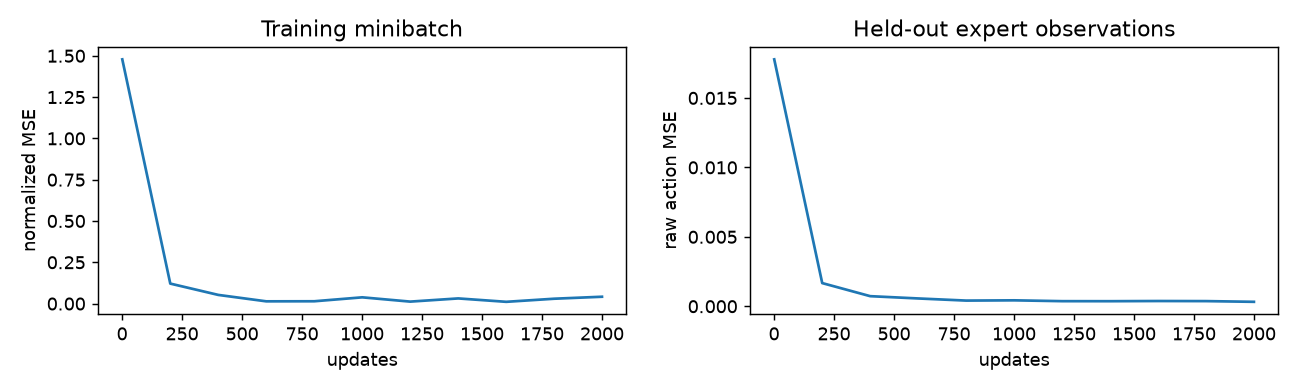

In [8]:
curve = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(curve.step, curve.train_normalized_mse)
axes[0].set(xlabel="updates", ylabel="normalized MSE", title="Training minibatch")
axes[1].plot(curve.step, curve.val_action_mse)
axes[1].set(xlabel="updates", ylabel="raw action MSE", title="Held-out expert observations")
fig.tight_layout(); fig.savefig(OUT / "bc_training.png", dpi=130)
display(Image(filename=str(OUT / "bc_training.png"))); plt.close(fig)

In [17]:
import copy, time
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt

PREDICTION = "我预测收敛速度排名: adam ≈ adamw > rmsprop > sgd_mom > sgd; 最终val差距: 很小"

OPTIMIZERS = {
    "sgd":      lambda p: torch.optim.SGD(p, lr=1e-2),                    # 注意 lr 比 Adam 大一个量级
    "sgd_mom":  lambda p: torch.optim.SGD(p, lr=1e-2, momentum=0.9),
    "rmsprop":  lambda p: torch.optim.RMSprop(p, lr=1e-3),
    "adam":     lambda p: torch.optim.Adam(p, lr=1e-3),
    "adamw":    lambda p: torch.optim.AdamW(p, lr=1e-3, weight_decay=1e-2),
}

def train_with(opt_factory, updates=UPDATES, seed=SEED):
    model = Actor(train["obs"].mean(0), np.maximum(train["obs"].std(0), .01),
                  train["expert_action"].mean(0), np.maximum(train["expert_action"].std(0), .01))
    x  = torch.tensor(train["obs"], dtype=torch.float32)
    y  = torch.tensor(train["expert_action"], dtype=torch.float32)
    vx = torch.tensor(val["obs"], dtype=torch.float32)
    vy = torch.tensor(val["expert_action"], dtype=torch.float32)
    opt = opt_factory(model.parameters())
    rng = np.random.default_rng(seed)          # 同一 seed → 同一批次序列，公平对照
    curve = []
    t0 = time.time()
    for step in range(updates):
        idx = torch.as_tensor(rng.integers(0, len(x), size=256))
        pred = model.standardized(x[idx])
        target = (y[idx] - model.a_mean) / model.a_std
        loss = ((pred - target) ** 2).mean()
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.)
        opt.step()
        if step % max(1, updates // 20) == 0 or step == updates - 1:
            with torch.inference_mode():
                vmse = ((model(vx) - vy) ** 2).mean().item()
            curve.append(dict(step=step + 1, val_mse=vmse))
    return pd.DataFrame(curve).assign(seconds=round(time.time() - t0, 1)), model

results = {name: train_with(f) for name, f in OPTIMIZERS.items()}

fig, ax = plt.subplots(figsize=(8, 4))
for name, (curve, _) in results.items():
    ax.plot(curve.step, curve.val_mse, label=name)
ax.set(xlabel="updates", ylabel="val action MSE", yscale="log", title="Optimizer comparison (same seed, same batches)")
ax.legend(); plt.tight_layout(); plt.show()

summary = pd.DataFrame({n: {"final_val_mse": c.val_mse.iloc[-1], "seconds": c.seconds.iloc[0]}
                        for n, (c, _) in results.items()}).T.sort_values("final_val_mse")
display(summary)

print(PREDICTION)

/var/folders/g8/dz5dbhjx1715c1816870h0fr0000gn/T/ipykernel_4527/3409070060.py:47: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax.legend(); plt.tight_layout(); plt.show()


,final_val_mse,seconds
adamw,0.000299,0.7
adam,0.000304,0.7
sgd_mom,0.000389,0.6
rmsprop,0.000737,0.7
sgd,0.002476,0.6


我预测收敛速度排名: adam ≈ adamw > rmsprop > sgd_mom > sgd; 最终val差距: 很小


In [18]:
model = Actor(train["obs"].mean(0), np.maximum(train["obs"].std(0), .01),
              train["expert_action"].mean(0), np.maximum(train["expert_action"].std(0), .01))
x = torch.tensor(train["obs"], dtype=torch.float32)
t = (torch.tensor(train["expert_action"], dtype=torch.float32) - model.a_mean) / model.a_std
opt = torch.optim.LBFGS(model.parameters(), max_iter=100, line_search_fn="strong_wolfe")

def closure():
    opt.zero_grad(set_to_none=True)
    loss = ((model.standardized(x) - t) ** 2).mean()
    loss.backward()
    return loss

opt.step(closure)   # 一次 step = 内部最多 100 次迭代
with torch.inference_mode():
    vx = torch.tensor(val["obs"], dtype=torch.float32)
    vy = torch.tensor(val["expert_action"], dtype=torch.float32)
    print("LBFGS val MSE:", ((model(vx) - vy) ** 2).mean().item())

LBFGS val MSE: 0.0003755395009648055


## 6 · 冻结与加载：你部署的必须是可恢复的模型

checkpoint 包含权重和归一化参数。保存后重新加载，确认同一批输入得到同一输出，再进入仿真。
这里的“部署”指**重新加载策略并接入模拟器**，还没有接真机。

In [9]:
def save_reload(model, name):
    path = OUT / f"{name}.pt"
    probe = torch.tensor(val["obs"][:32], dtype=torch.float32)
    with torch.inference_mode():
        before = model(probe).clone()
    torch.save(model.state_dict(), path)
    restored = copy.deepcopy(model)
    restored.load_state_dict(torch.load(path, weights_only=True, map_location="cpu"))
    with torch.inference_mode():
        torch.testing.assert_close(before, restored(probe), rtol=0, atol=0)
    print(f"{name}: reload PASS | SHA256 {hashlib.sha256(path.read_bytes()).hexdigest()[:16]}")
    return restored

bc = save_reload(bc, "bc")

bc: reload PASS | SHA256 2445e2c91e7104d6


## 07 · 优化器可视化实验室：看见更新规则的"性格"

In [ ]:
import numpy as np, torch, matplotlib.pyplot as plt

def quadratic(p):   # 病态山谷：y 方向曲率是 x 的 50 倍（条件数 50）
    return 0.5 * (p[0]**2 + 50 * p[1]**2)

def rosenbrock(p):  # 弯曲山谷：最优路径本身是条弧线
    return (1 - p[0])**2 + 100 * (p[1] - p[0]**2)**2

# 每个优化器配的 lr 是"能展示其典型步态"的值，不是公平 benchmark——公平对照见实验三
CONFIGS = {
    "sgd":     (lambda p: torch.optim.SGD(p, lr=0.035), "tab:blue"),
    "sgd_mom": (lambda p: torch.optim.SGD(p, lr=0.01, momentum=0.9), "tab:orange"),
    "rmsprop": (lambda p: torch.optim.RMSprop(p, lr=0.05), "tab:green"),
    "adam":    (lambda p: torch.optim.Adam(p, lr=0.2), "tab:red"),
}

def run(loss_fn, start, steps=120):
    paths = {}
    for name, (fac, _) in CONFIGS.items():
        p = torch.nn.Parameter(torch.tensor(start, dtype=torch.float32))
        opt = fac([p]); traj = [p.detach().numpy().copy()]
        for _ in range(steps):
            opt.zero_grad(); loss_fn(p).backward(); opt.step()
            traj.append(p.detach().numpy().copy())
        paths[name] = np.array(traj)
    return paths

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (fn, start, lim, title) in zip(axes, [
        (quadratic, [-9.0, 1.5], (-10, 10, -3, 3), "quadratic (n=50)"),
        (rosenbrock, [-1.5, 2.0], (-2, 2, -1, 3), "Rosenbrock ")]):
    gx, gy = np.meshgrid(np.linspace(lim[0], lim[1], 200), np.linspace(lim[2], lim[3], 200))
    z = np.array([fn(torch.tensor([a, b])).item() for a, b in zip(gx.ravel(), gy.ravel())]).reshape(gx.shape)
    ax.contour(gx, gy, np.log1p(z), levels=25, cmap="Greys", alpha=0.5)
    for name, traj in run(fn, start).items():
        ax.plot(traj[:, 0], traj[:, 1], ".-", ms=3, lw=1, label=name, color=CONFIGS[name][1])
    ax.set_title(title); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [20]:
from matplotlib.animation import FuncAnimation, PillowWriter
paths = run(quadratic, [-9.0, 1.5])
fig, ax = plt.subplots(figsize=(7, 4))
gx, gy = np.meshgrid(np.linspace(-10, 10, 200), np.linspace(-3, 3, 200))
z = 0.5 * (gx**2 + 50 * gy**2)
ax.contour(gx, gy, np.log1p(z), levels=25, cmap="Greys", alpha=0.5)
lines = {n: ax.plot([], [], ".-", ms=4, lw=1, label=n, color=c)[0] for n, (_, c) in CONFIGS.items()}
ax.legend(fontsize=8); ax.set(xlim=(-10, 10), ylim=(-3, 3))
def frame(i):
    for n, ln in lines.items():
        ln.set_data(paths[n][:i+1, 0], paths[n][:i+1, 1])
    return list(lines.values())
FuncAnimation(fig, frame, frames=120, blit=True).save("optimizer_race.gif", writer=PillowWriter(fps=20))
plt.close(fig); print("saved optimizer_race.gif")  # 在文件浏览器里打开看

saved optimizer_race.gif


## 实验二 · 真实 BC 训练的动力学仪表盘
回答：训练循环内部到底发生了什么？（这四个仪表也是你以后 debug 大模型训练的标配）

In [25]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["Hiragino Sans GB", "PingFang HK", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
import matplotlib; print(matplotlib.get_backend())

inline


findfont: Failed to find font weight normal, now using 300.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


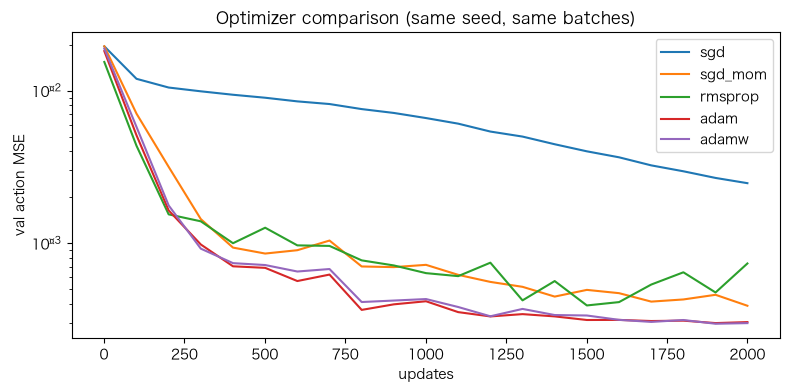

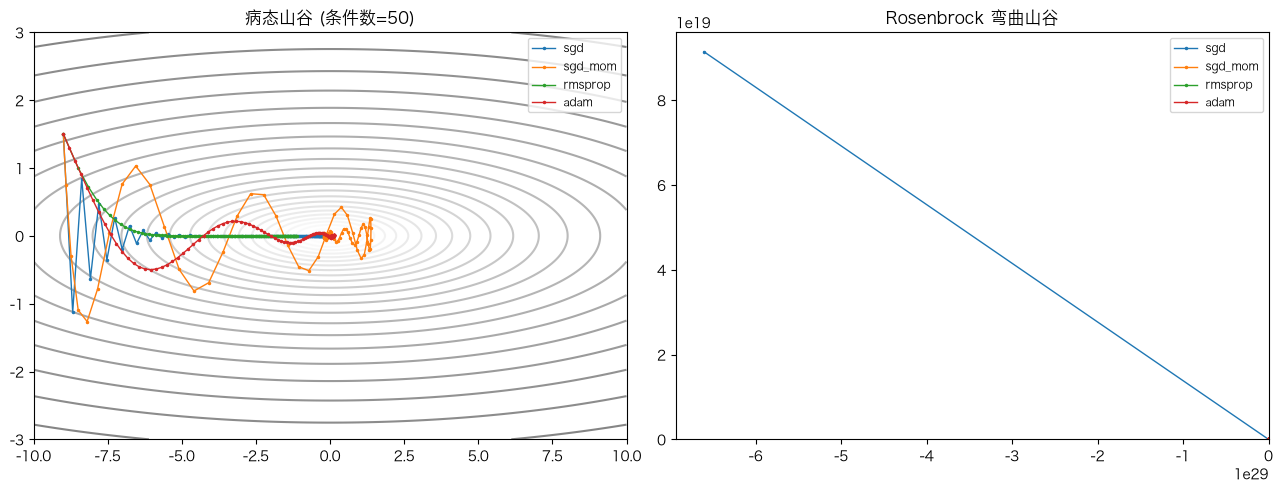

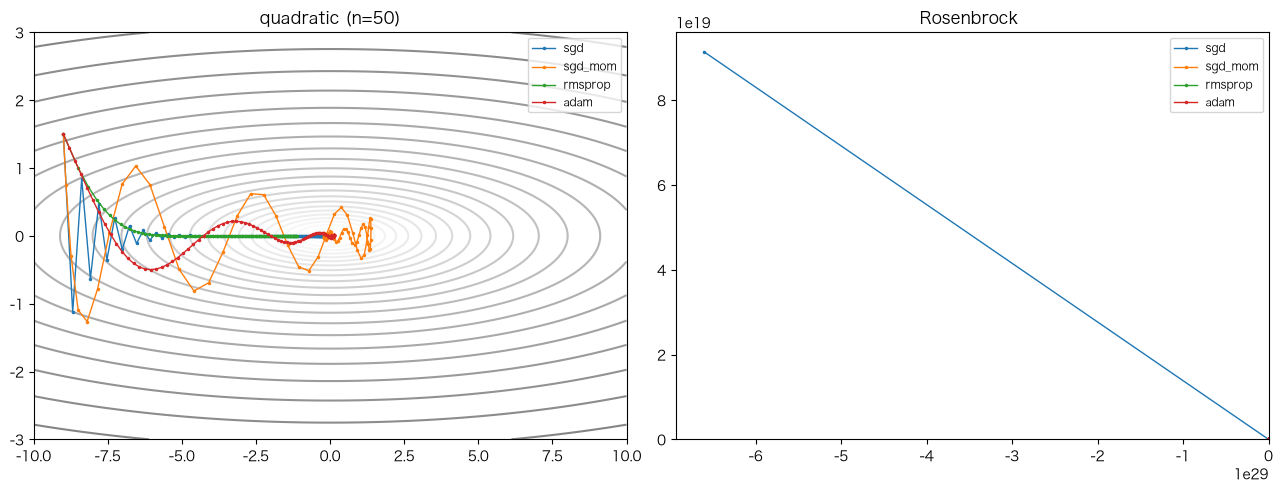

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

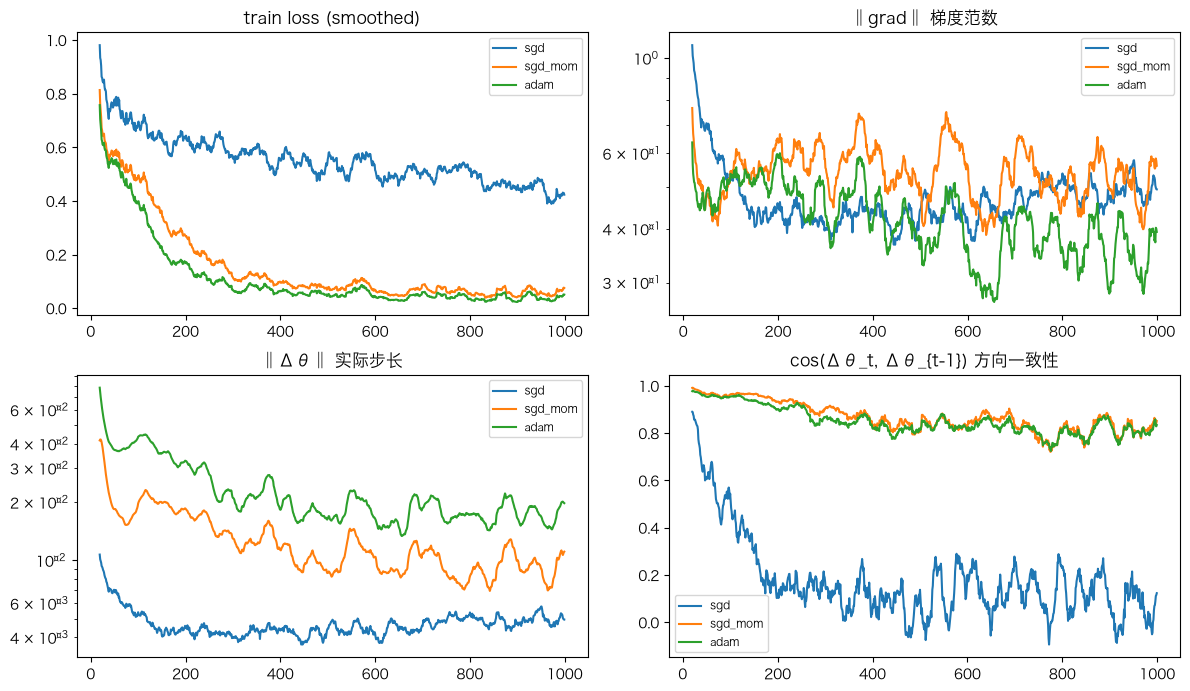

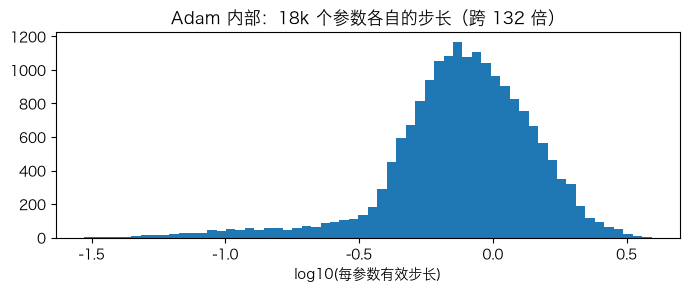

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

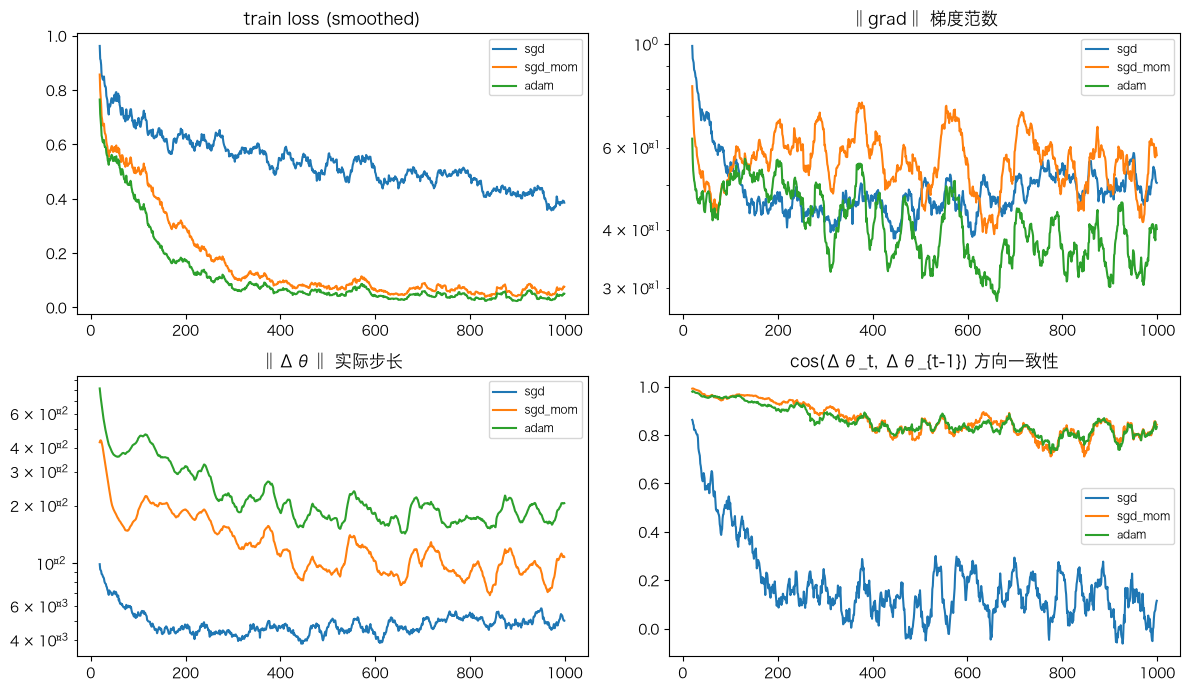

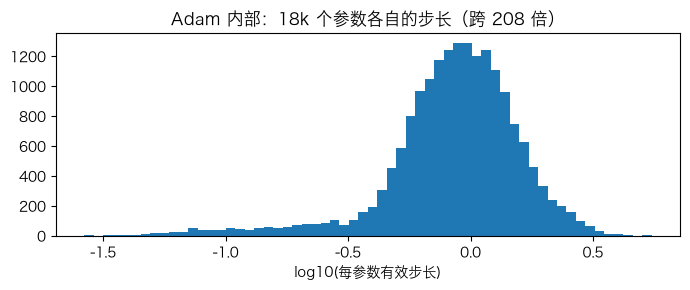

In [24]:
import numpy as np, pandas as pd, torch, matplotlib.pyplot as plt

def instrumented_train(opt_name, opt_factory, updates=1000, seed=SEED):
    model = Actor(train["obs"].mean(0), np.maximum(train["obs"].std(0), .01),
                  train["expert_action"].mean(0), np.maximum(train["expert_action"].std(0), .01))
    x = torch.tensor(train["obs"], dtype=torch.float32)
    y = torch.tensor(train["expert_action"], dtype=torch.float32)
    opt = opt_factory(model.parameters())
    rng = np.random.default_rng(seed)
    rec, prev_update = [], None
    for step in range(updates):
        idx = torch.as_tensor(rng.integers(0, len(x), size=256))
        loss = ((model.standardized(x[idx]) - (y[idx] - model.a_mean) / model.a_std) ** 2).mean()
        opt.zero_grad(set_to_none=True); loss.backward()
        grad_norm = torch.sqrt(sum((p.grad**2).sum() for p in model.parameters())).item()
        before = torch.cat([p.detach().flatten().clone() for p in model.parameters()])
        opt.step()
        after = torch.cat([p.detach().flatten() for p in model.parameters()])
        update = after - before
        cos = (torch.dot(update, prev_update) / (update.norm() * prev_update.norm() + 1e-12)).item() if prev_update is not None else np.nan
        prev_update = update.clone()
        rec.append(dict(step=step, loss=loss.item(), grad_norm=grad_norm,
                        update_norm=update.norm().item(), cos_prev=cos))
    return pd.DataFrame(rec), model, opt

runs = {n: instrumented_train(n, f) for n, f in
        {"sgd": lambda p: torch.optim.SGD(p, lr=1e-2),
         "sgd_mom": lambda p: torch.optim.SGD(p, lr=1e-2, momentum=0.9),
         "adam": lambda p: torch.optim.Adam(p, lr=1e-3)}.items()}

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for n, (df, _, _) in runs.items():
    axes[0, 0].plot(df.step, df.loss.rolling(20).mean(), label=n)
    axes[0, 1].plot(df.step, df.grad_norm.rolling(20).mean(), label=n)
    axes[1, 0].plot(df.step, df.update_norm.rolling(20).mean(), label=n)
    axes[1, 1].plot(df.step, df.cos_prev.rolling(20).mean(), label=n)
for ax, t in zip(axes.ravel(), ["train loss (smoothed)", "‖grad‖ 梯度范数",
                                "‖Δθ‖ 实际步长", "cos(Δθ_t, Δθ_{t-1}) 方向一致性"]):
    ax.set_title(t); ax.legend(fontsize=8); ax.set_yscale("log" if "‖" in t else "linear")
plt.tight_layout(); plt.show()

# Adam 的"每参数波动率定价"直接画出来：有效步长 = lr / (sqrt(v_hat)+eps)
_, _, adam_opt = runs["adam"]
eff = np.concatenate([(1e-3 / (adam_opt.state[p]["exp_avg_sq"].sqrt() + 1e-8)).flatten().numpy()
                      for p in adam_opt.param_groups[0]["params"] if p in adam_opt.state])
plt.figure(figsize=(7, 3))
plt.hist(np.log10(eff), bins=60)
plt.xlabel("log10(每参数有效步长)"); plt.title(f"Adam 内部：18k 个参数各自的步长（跨 {eff.max()/eff.min():.0f} 倍）")
plt.tight_layout(); plt.show()

## 实验三 · lr 敏感性：为什么 Adam 是默认
看什么：两条 U 形线。adam 的"好区间"横跨约两个数量级；sgd 的窄得多、且太大直接发散（截顶在 10）。 所谓"默认用 Adam"的工程含义 = 你随手一个 lr 落在好盆地里的概率大。sgd 的低谷点未必更差—— 它只是需要你付出调参成本。大规模视觉任务愿意付这个成本换泛化，快速迭代的研究不愿意。

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

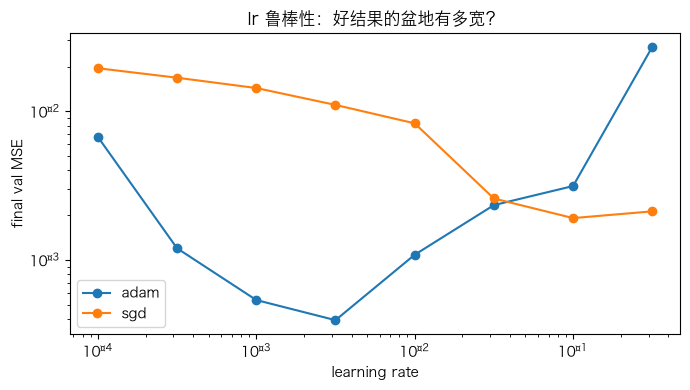

In [26]:
lrs = np.logspace(-4, -0.5, 8)
rows = []
for lr in lrs:
    for name, fac in {"sgd": lambda p, lr=lr: torch.optim.SGD(p, lr=lr),
                      "adam": lambda p, lr=lr: torch.optim.Adam(p, lr=lr)}.items():
        df, model, _ = instrumented_train(name, fac, updates=600)
        with torch.inference_mode():
            vmse = ((model(torch.tensor(val["obs"], dtype=torch.float32))
                     - torch.tensor(val["expert_action"], dtype=torch.float32))**2).mean().item()
        rows.append(dict(optimizer=name, lr=lr, val_mse=min(vmse, 10.)))
sweep = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(7, 4))
for n, g in sweep.groupby("optimizer"):
    ax.plot(g.lr, g.val_mse, "o-", label=n)
ax.set(xscale="log", yscale="log", xlabel="learning rate", ylabel="final val MSE",
       title="lr 鲁棒性：好结果的盆地有多宽？")
ax.legend(); plt.tight_layout(); plt.show()

## 实验四 · 标准化 × 优化器：自适应步长在替谁干活

In [27]:
def train_variant(standardize, opt_factory, updates=1000):
    if standardize:
        model = Actor(train["obs"].mean(0), np.maximum(train["obs"].std(0), .01),
                      train["expert_action"].mean(0), np.maximum(train["expert_action"].std(0), .01))
    else:  # 均值 0、方差 1 = 关掉输入标准化，模型直接吃原始尺度
        model = Actor(np.zeros_like(train["obs"].mean(0)), np.ones_like(train["obs"].std(0)),
                      train["expert_action"].mean(0), np.maximum(train["expert_action"].std(0), .01))
    x = torch.tensor(train["obs"], dtype=torch.float32)
    y = torch.tensor(train["expert_action"], dtype=torch.float32)
    opt = opt_factory(model.parameters()); rng = np.random.default_rng(SEED)
    for step in range(updates):
        idx = torch.as_tensor(rng.integers(0, len(x), size=256))
        loss = ((model.standardized(x[idx]) - (y[idx] - model.a_mean) / model.a_std) ** 2).mean()
        opt.zero_grad(set_to_none=True); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.); opt.step()
    with torch.inference_mode():
        return ((model(torch.tensor(val["obs"], dtype=torch.float32))
                 - torch.tensor(val["expert_action"], dtype=torch.float32))**2).mean().item()

grid = {(std, name): train_variant(std, fac)
        for std in [True, False]
        for name, fac in {"sgd": lambda p: torch.optim.SGD(p, lr=1e-2),
                          "adam": lambda p: torch.optim.Adam(p, lr=1e-3)}.items()}
result = pd.DataFrame([{"标准化": s, "优化器": n, "val_mse": v} for (s, n), v in grid.items()])
display(result.pivot(index="优化器", columns="标准化", values="val_mse"))

标准化,False,True
优化器,,
adam,0.001476,0.000338
sgd,0.011257,0.006733


## 7 · 真正的闭环评测：每一步都重新读取环境

`evaluate` 不是把验证标签再算一遍 MSE。它对每个策略重新 reset，然后重复：
```python
action = policy(observation)
observation, reward, terminated, truncated, info = env.step(action)
```

比较 4 个基线：零动作、随机动作、专家、BC。所有策略使用相同的 30 个初始种子，避免“某个模型恰好拿到更容易的目标”。

**评测前预测**：离线 MSE 降了，BC 会在所有初始状态成功吗？专家是否足够可靠，值得模仿？

,,episodes,success_rate,successes,mean_distance_cm
policy,condition,,,,
bc,delay_0,30,0.600000,18,4.167435
random,delay_0,30,0.033333,1,17.838807
teacher,delay_0,30,1.000000,30,0.053426
zero,delay_0,30,0.000000,0,24.929199


**回放：BC；按模拟状态绘制，以半速播放，便于观察。**


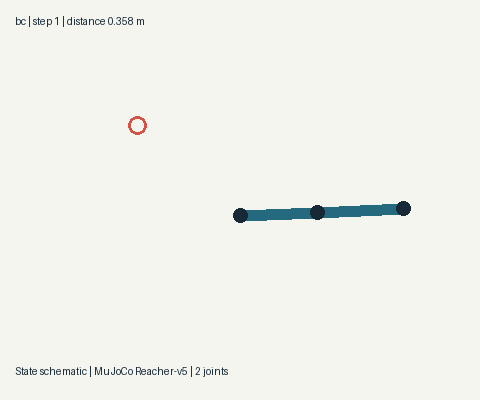

In [10]:
EVAL_SEEDS = list(range(10000, 10000 + N_EVAL))
assert not set(EVAL_SEEDS) & (set(train["episode"]) | set(val["episode"]))
rows = []
for name in ["zero", "random", "teacher"]:
    rows += evaluate(None, name, EVAL_SEEDS, 0, OUT)
rows += evaluate(bc, "bc", EVAL_SEEDS, 0, OUT)

def score_table(frame):
    table = frame.groupby(["policy", "condition"]).agg(
        episodes=("seed", "count"), mean_distance_m=("last10_mean_distance", "mean"),
        success_rate=("success", "mean"), successes=("success", "sum"))
    table["mean_distance_cm"] = table.pop("mean_distance_m") * 100
    return table

baseline_rows = list(rows)  # 保留基线，后续重跑评测格不会累积重复行
display(score_table(pd.DataFrame(rows)))
display(Markdown("**回放：BC；按模拟状态绘制，以半速播放，便于观察。**"))
show_gif(OUT / "bc.gif")

## 8 · 失败假设：模型会走到训练集没有覆盖好的状态

专家演示通常沿着“专家会走的路径”；学生犯一点错后，可能到达别的状态。它对这些状态的纠错能力未必好。这叫分布偏移（distribution shift），是模仿学习中的核心问题。

DAgger 的核心想法：让学生执行，收集它实际访问的状态，再请专家给这些状态打正确动作标签，把新数据并入训练。
这里实现的是**单轮、20% 专家 / 80% 学生混合行为的 DAgger 式教学变体**，不是完整多轮论文实验。

但“改进了”可能只是因为训练时间更长，或因为标签更多。我们必须安排对照：

| 组 | 数据 | 从哪里开始 | 追加更新 |
|---|---|---|---|
| bc | 原始专家轨迹 | 首次训练 | 0 |
| more_updates | 原始专家轨迹 | 同一个 BC checkpoint | S |
| more_expert | 原始 + 新普通专家轨迹 | 同一个 BC checkpoint | S |
| dagger | 原始 + 学生访问状态的专家纠正 | 同一个 BC checkpoint | S |

后两组新增标签数相同、初始种子相同；三组使用相同更新步数、batch 和优化器重置规则。归一化统计保持原始训练集不变。公平比较依然不等于覆盖了所有混杂因素。

**在跑下一格之前填写**：如果 dagger 只赢 BC、却没赢 more_updates，你会如何改写结论？

In [11]:
EXTRA_SEEDS = list(range(2000, 2000 + N_EXTRA))
assert not set(EXTRA_SEEDS) & set(EVAL_SEEDS)
corrective = collect(EXTRA_SEEDS, learner=bc, beta=.2, rng_seed=SEED)
ordinary = collect(EXTRA_SEEDS, rng_seed=SEED)
assert len(corrective["obs"]) == len(ordinary["obs"])
audit(corrective); audit(ordinary)
np.savez_compressed(OUT / "raw_dagger.npz", **corrective)
np.savez_compressed(OUT / "raw_more_expert.npz", **ordinary)

coverage = []
for name, data in [("original", train), ("extra_expert", ordinary), ("corrective", corrective)]:
    z = (data["obs"] - train["obs"].mean(0)) / np.maximum(train["obs"].std(0), .01)
    coverage.append(dict(data=name, labels=len(z),
                         mean_distance_cm=np.linalg.norm(data["obs"][:, -2:], axis=1).mean()*100,
                         fraction_any_feature_over_3std=np.mean(np.any(np.abs(z)>3, axis=1))))
display(pd.DataFrame(coverage))
print("3σ 比例只是粗略覆盖诊断，不是高维分布距离或 DAgger 有效性的证明。")

,data,labels,mean_distance_cm,fraction_any_feature_over_3std
0,original,4000,5.570253,0.0855
1,extra_expert,2000,5.835701,0.0930
2,corrective,2000,6.507717,0.0985


3σ 比例只是粗略覆盖诊断，不是高维分布距离或 DAgger 有效性的证明。


In [12]:
variants = {"bc": bc}
for name, addition in [("more_updates", None), ("more_expert", ordinary), ("dagger", corrective)]:
    data = train if addition is None else {k: np.concatenate([train[k], addition[k]]) for k in train}
    model = copy.deepcopy(bc)
    history += train_policy(model, data, val, UPDATES, SEED + 1, name)
    variants[name] = save_reload(model, name)
pd.DataFrame(history).to_csv(OUT / "training.csv", index=False)

more_updates: reload PASS | SHA256 35406d4b9dc1cf3a


more_expert: reload PASS | SHA256 03b04dd37b7151f3


dagger: reload PASS | SHA256 cf9272c4d4fe45b6


## 9 · 复评与压力测试：数据纠错能否顺便解决延迟？

先评正常反馈，再把学生看到的观测延迟 2 步，即 40 ms；执行器仍每 20 ms 接收一次命令。我们只改变观测时效，没有改变仿真的动力学。

这是新的失败来源。不能因为一种方法修复分布偏移，就假定它解决通信、时间同步和执行延迟。
**先预测**：dagger 在正常情况下的优势，会在延迟下保留多少？

      policy condition  n     mean   ci_low  ci_high
        zero   delay_0 30 0.249292 0.213593 0.285375
      random   delay_0 30 0.178388 0.146687 0.213147
     teacher   delay_0 30 0.000534 0.000449 0.000621
          bc   delay_0 30 0.041674 0.025346 0.060699
          bc   delay_2 30 0.169981 0.141524 0.201218
more_updates   delay_0 30 0.025076 0.015942 0.035217
more_updates   delay_2 30 0.158692 0.126733 0.189351
 more_expert   delay_0 30 0.033940 0.015679 0.055055
 more_expert   delay_2 30 0.154914 0.124240 0.186752
      dagger   delay_0 30 0.013679 0.010258 0.017823
      dagger   delay_2 30 0.126074 0.099456 0.153455


episodes  success_rate  successes  mean_distance_cm
policy       condition                                                     
bc           delay_0          30        0.6000         18            4.1674
             delay_2          30        0.0000          0           16.9981
dagger       delay_0          30        0.8667         26            1.3679
             delay_2          30        0.1333          4           12.6074
more_expert  delay_0          30        0.7333         22            3.3940
             delay_2          30        0.0333          1           15.4914
more_updates delay_0          30        0.6667         20            2.5076
             delay_2          30        0.0667          2           15.8692
random       delay_0          30        0.0333          1           17.8388
teacher      delay_0          30        1.0000         30            0.0534
zero         delay_0          30        0.0000          0           24.9292

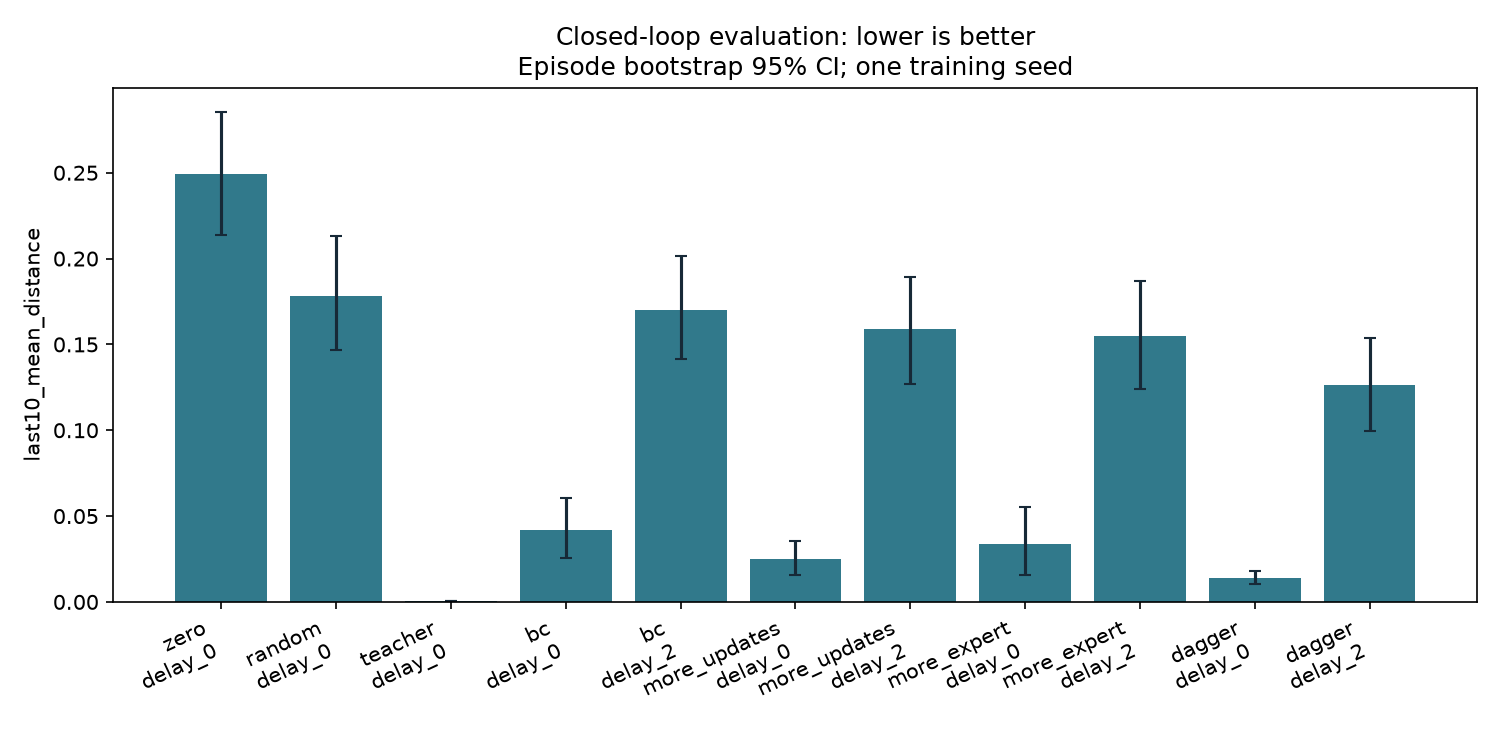

In [13]:
rows = list(baseline_rows)
for name, model in variants.items():
    if name != "bc":  # BC 的正常反馈评测已经完成
        rows += evaluate(model, name, EVAL_SEEDS, 0, OUT)
    rows += evaluate(model, name, EVAL_SEEDS, 2, OUT)
frame = summarize(rows, OUT, "last10_mean_distance", "Closed-loop evaluation: lower is better")
write_paired_delta(frame, "bc", "last10_mean_distance", OUT)
table = score_table(frame)
display(table.round(4))
display(Image(filename=str(OUT / "comparison.png")))

## 10 · 分开看离线拟合、执行误差和不确定性

下面把离线 action MSE 和正常执行距离放到同一张表，但不把它们合成一个分数。
置信区间按独立 episode 重采样；配对比较按同一 seed 的两个策略取差。

**统计单位是 episode，不是轨迹里的每一帧。** 这些区间只描述当前一个训练 seed 的评测变化，不包含重新训练的随机性。要声称学习方法稳定更好，下一步还要跑多个训练 seeds。

In [14]:
offline = pd.DataFrame(history).groupby("phase").tail(1).set_index("phase")[["val_action_mse"]]
online = table.xs("delay_0", level="condition")[["mean_distance_cm", "success_rate"]]
display(offline.join(online).sort_values("mean_distance_cm"))

def paired_comparison(candidate, reference, condition="delay_0"):
    pivot = frame[frame.condition == condition].pivot(index="seed", columns="policy", values="last10_mean_distance")
    delta = (pivot[candidate] - pivot[reference]).dropna().to_numpy() * 100
    rng = np.random.default_rng(2026)
    means = rng.choice(delta, size=(3000, len(delta)), replace=True).mean(axis=1)
    return dict(candidate=candidate, reference=reference, condition=condition,
                delta_cm=delta.mean(), ci_low_cm=np.quantile(means, .025),
                ci_high_cm=np.quantile(means, .975), paired_episodes=len(delta))

paired = pd.DataFrame([paired_comparison("dagger", ref) for ref in ["bc", "more_updates", "more_expert"]])
paired.to_csv(OUT / "controlled_paired_deltas.csv", index=False)
display(paired.round(4))
print("delta < 0 表示 dagger 距离更小；区间跨 0 时，本次评测不足以清晰区分。")

,val_action_mse,mean_distance_cm,success_rate
phase,,,
dagger,0.000446,1.367870,0.866667
more_updates,0.000247,2.507603,0.666667
more_expert,0.000215,3.394014,0.733333
bc,0.000320,4.167435,0.600000


,candidate,reference,condition,delta_cm,ci_low_cm,ci_high_cm,paired_episodes
0,dagger,bc,delay_0,-2.7996,-4.6703,-1.2684,30
1,dagger,more_updates,delay_0,-1.1397,-1.9886,-0.3502,30
2,dagger,more_expert,delay_0,-2.0261,-4.1043,-0.3945,30


delta < 0 表示 dagger 距离更小；区间跨 0 时，本次评测不足以清晰区分。


## 11 · 失败归因：对同一个困难初始状态看回放

下面自动选 BC 正常反馈中误差最大的 episode。选择规则先明确：我们是在诊断 BC 失败，不是挑一个最好看的例子证明算法胜出。总体结论仍看上面的全部 episodes。

观察：学生是朝错误方向走、接近后振荡，还是停在目标附近但不够准确？加入纠正后，同一个目标发生了什么？仅靠 GIF 不能断言控制理论原因，需要下一次实验验证。

Worst BC development seed: 10015


**bc：最后 10 步平均误差 21.33 cm**


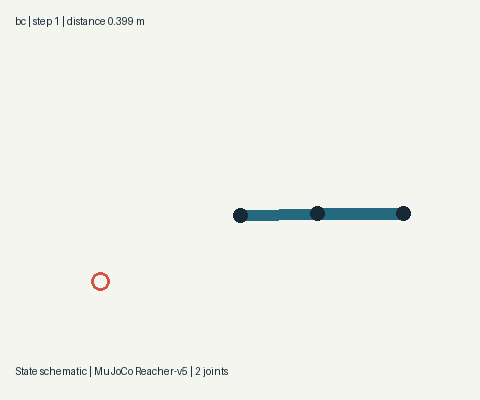

**dagger：最后 10 步平均误差 0.51 cm**


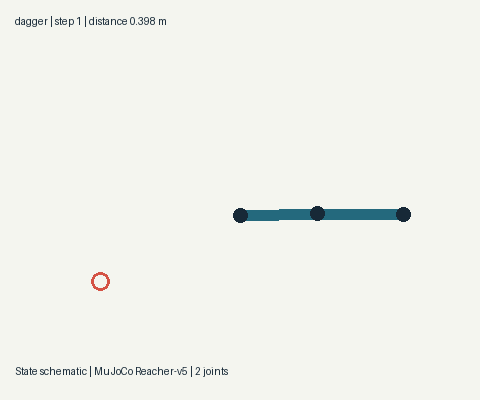

In [15]:
bc_rows = frame[(frame.policy == "bc") & (frame.condition == "delay_0")]
WORST_SEED = int(bc_rows.loc[bc_rows.last10_mean_distance.idxmax(), "seed"])
REVIEW_DIR = OUT / "failure_review"
REVIEW_DIR.mkdir(exist_ok=True)
print("Worst BC development seed:", WORST_SEED)
for name in ["bc", "dagger"]:
    result = evaluate(variants[name], name, [WORST_SEED], 0, REVIEW_DIR)[0]
    display(Markdown(f"**{name}：最后 10 步平均误差 {result['last10_mean_distance']*100:.2f} cm**"))
    show_gif(REVIEW_DIR / f"{name}.gif")

## 12 · 写复盘：把实验变成你自己的判断

下面会保存实际数值和你的回答到 `review.md`。写完后可读本目录的 `参考复盘.md`，对照一次已运行结果的讲评。**请修改回答后重跑这格**；自动生成数字不等于完成研究复盘。

| 问题 | 及格标准 |
|---|---|
| 我的模型学了什么？ | 能说清观测、动作、标签来源和单位 |
| 为什么 MSE 不能替代 rollout？ | 能解释动作影响后续状态分布 |
| 什么改动有效？ | 同时比较 BC、计算预算对照与标签预算对照 |
| 我的结论有多强？ | 知道一个训练 seed、开发集、二维无接触任务的边界 |
| 下一轮怎么做？ | 只改一个变量，事先写出假设和判定指标 |

In [16]:
MY_REVIEW = {
    "离线误差与执行表现": "待填写：用本次两项数值解释它们是否一致。",
    "公平对照的结论": "待填写：dagger 相对 more_updates / more_expert 的差值与区间说明什么？",
    "最坏案例观察": "待填写：我看到的动作现象是……还不能确定的原因是……",
    "延迟测试": "待填写：40 ms 延迟带来了什么变化？",
    "下一轮假设": "待填写：我只改……预期……用……判断；其余参数冻结。",
}
elapsed = time.perf_counter() - START
summary_text = table.round(4).to_string()
report = "# 我的第一次机器人学习闭环\n\n"
report += f"配置：{manifest['args']}\n\n最初预测：{MY_PREDICTION}\n\n"
report += "实际执行指标：\n```text\n" + summary_text + "\n```\n\n"
report += "配对比较（cm）：\n```text\n" + paired.round(4).to_string(index=False) + "\n```\n\n"
report += "\n\n".join(f"## {key}\n\n{answer}" for key, answer in MY_REVIEW.items())
report += "\n\n边界：一个训练 seed；开发评测；MuJoCo 低维无接触任务；无真机验证。\n"
(OUT / "review.md").write_text(report, encoding="utf-8")
(OUT / "notebook_summary.json").write_text(json.dumps({"elapsed_seconds": elapsed,
    "worst_bc_seed": WORST_SEED, "config": manifest["args"],
    "all_cells_execution": "reached final computational cell"}, indent=2), encoding="utf-8")
print(f"从第 2 个代码格至此：{elapsed:.1f} 秒（交互运行时包含阅读停留时间）。")
print("模型、数据、图表与 review.md：", OUT)
display(Markdown("**你已完成：采集 → 审计 → 训练 → 加载 → 执行 → 纠错 → 对照 → 复盘。下一步是填写上面的回答。**"))

从第 2 个代码格至此：8.6 秒（交互运行时包含阅读停留时间）。
模型、数据、图表与 review.md： robot_learning_loops/runs/notebook01-20260909-221649-436000


**你已完成：采集 → 审计 → 训练 → 加载 → 执行 → 纠错 → 对照 → 复盘。下一步是填写上面的回答。**

## 13 · 第二遍练习：先选一个，再执行

按顺序递进，每次保留一份新实验目录和复盘：

1. **数据效率**：只把 `N_TRAIN` 改成 20 或 40，固定 `N_EXTRA`、更新数和评测条件。画数据量与闭环距离的关系；不要把不同标签预算混作算法优劣。
2. **结果稳定性**：保持数据与配置，运行训练 seeds 7、11、19。比较每个训练 seed 的配对改进，别把所有帧拼一起制造很窄的区间。
3. **时间语义**：把评测 delay 改为 0、1、2、4，画性能曲线。下一轮再单独试“训练时模拟延迟”或观测历史输入；不要同时改网络、数据和延迟。
4. **最终检验**：在开发评测上确定方案后冻结代码、阈值和训练预算，再用未查看过的种子区间，例如 30000–30099，做最终测试。看过后不再称它为 untouched test。

完成标准不是“复述 DAgger”，而是能独立提出一个小问题、写出对照、跑出证据并解释失败。

## 14 · 这份练习在整个赛道的位置

| 接下来的项目 | 在已学闭环里替换哪个模块 | 新知识点 | 对应资料 |
|---|---|---|---|
| 奖励驱动控制 | 用奖励替代专家动作标签 | SAC / PPO、探索、replay buffer | `lessons/02_强化学习.md` + `loop02_reinforcement.py` |
| 世界模型与规划 | 学下一状态，再选动作 | 多步预测误差、CEM、MPC | `lessons/03_世界模型与规划.md` + `loop03_world_model.py` |
| 图像到动作序列 | 输入换成图像，输出换成动作块 | ACT、Diffusion Policy、闭环频率 | `lessons/04_ACT与DiffusionPolicy.md` |
| 视觉语言动作 | 增加任务语言与预训练模型 | SmolVLA、任务泛化、action interface | `lessons/05_VLA与真实执行.md` |

后两项提供上游代码和固定版本的启动计划，**尚未完成训练验证**。先完成前三个小闭环，再为具体问题申请云 GPU，更容易判断算力花在哪里。

## 随用随读的课件与一手资料

- 做第 2 节时读 [Gymnasium Reacher 官方文档](https://gymnasium.farama.org/environments/mujoco/reacher/) 的 Observation / Action / Reward。先能把文档映射到数组。
- 做第 5 节时读 [Stanford CS231n：神经网络训练](https://cs231n.github.io/neural-networks-3/) 的 loss、learning rate 与诊断曲线；这是通用训练知识。
- 做第 8 节后读 [DAgger 原论文](https://arxiv.org/abs/1011.0686) 的问题设定与算法，标出本练习和完整迭代算法的差别。
- 想理解“用模型算动作”的专家，再查 [MuJoCo 计算说明](https://mujoco.readthedocs.io/en/stable/computation/index.html) 的 forward / inverse dynamics；不必在第一次 BC 实验前读完。
- 本地讲义 `lessons/01_模仿学习与纠正数据.md` 与 `lessons/00_闭环地图.md` 给出更完整背景。

**向真实开源贡献迈一步**：把第二遍发现的一个可复现现象整理成数据审计工具、时间延迟测试或失败案例报告；先查上游是否已有类似测试，再形成最小复现。现在得到的是本地研究练习，不代表已经给外部项目贡献了代码。